In [47]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# Data Collection

In [48]:
shop_data = pd.read_csv("data/shop_smart_ecommerce.csv")

# Data Understanding

In [49]:
shop_data.head()
# shop_data.shape
# shop_data.describe()
# shop_data.info()
# shop_data.isnull().sum()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# Data Cleaning - But No null Values in Data

# EDA 

<Axes: xlabel='TrafficType', ylabel='Revenue'>

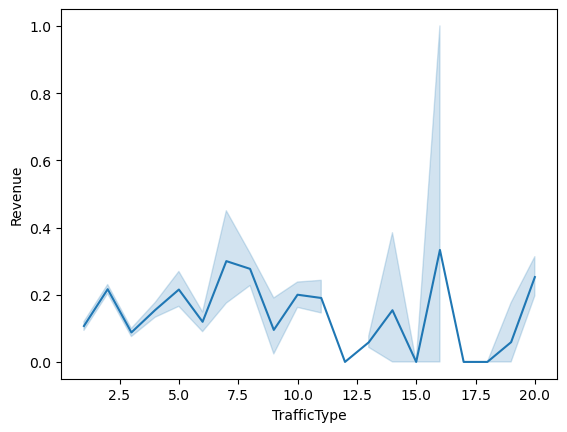

In [50]:
# Analysing Revenue Based on Traffic on store

sns.lineplot(
    data = shop_data,
    x = shop_data["TrafficType"],
    y = shop_data["Revenue"]
)

<Axes: xlabel='VisitorType', ylabel='TrafficType'>

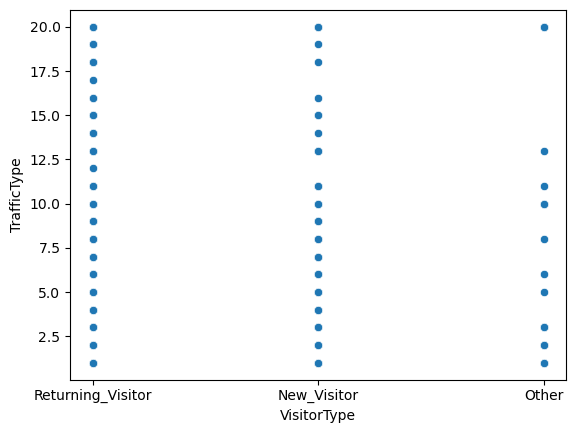

In [51]:
# Analysing Relation between TrafficType and VsistorType
sns.scatterplot(
    data = shop_data,
    x = shop_data["VisitorType"],
    y = shop_data["TrafficType"]
)

[Text(0, 0, '10551'), Text(0, 0, '1694'), Text(0, 0, '85')]

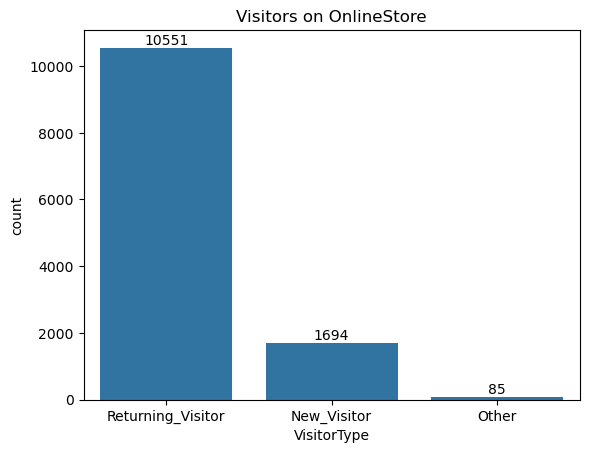

In [52]:
# Analysing visitors
visitors = shop_data["VisitorType"].value_counts()
ax = sns.barplot(visitors)
plt.title("Visitors on OnlineStore")
ax.bar_label(ax.containers[0])

<Axes: xlabel='Region', ylabel='Revenue'>

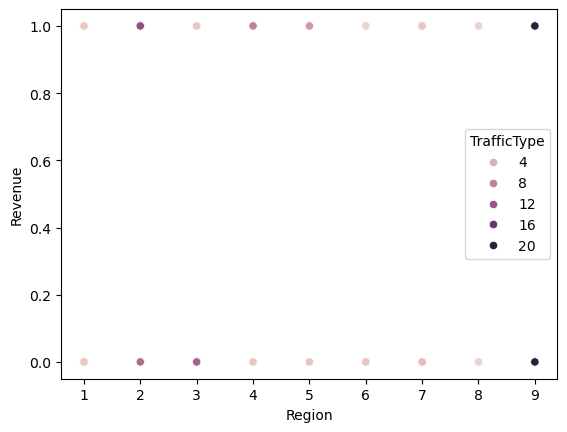

In [53]:
# Analysing Weekend wise revenue

# Numerical v/s Categorical in Bivariate Analysis
sns.scatterplot(
    data = shop_data,
    x = shop_data["Region"],
    y = shop_data["Revenue"],
    hue = shop_data["TrafficType"]
)

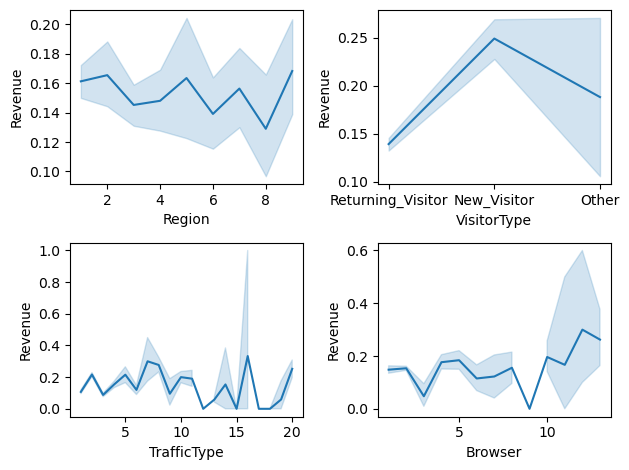

In [54]:
# Multiple Analysis

fig , axes = plt.subplots(2,2)

sns.lineplot(ax = axes[0,0], data = shop_data , x = shop_data["Region"] , y = shop_data["Revenue"])
sns.lineplot(ax = axes[0,1], data = shop_data , x = shop_data["VisitorType"] , y = shop_data["Revenue"])
sns.lineplot(ax = axes[1,0], data = shop_data , x = shop_data["TrafficType"] , y = shop_data["Revenue"])
sns.lineplot(ax = axes[1,1], data = shop_data , x = shop_data["Browser"] , y = shop_data["Revenue"])



plt.tight_layout()

# Divide Input and Output Feature

In [55]:
X = shop_data.drop(["Revenue"] , axis = 1)
y = shop_data["Revenue"]

# Numerical and Categorical Features

In [74]:
num_features = shop_data.select_dtypes(include = ["number" , "float64"]).columns
cat_features = shop_data.select_dtypes(include = ["object" , "category"]).columns

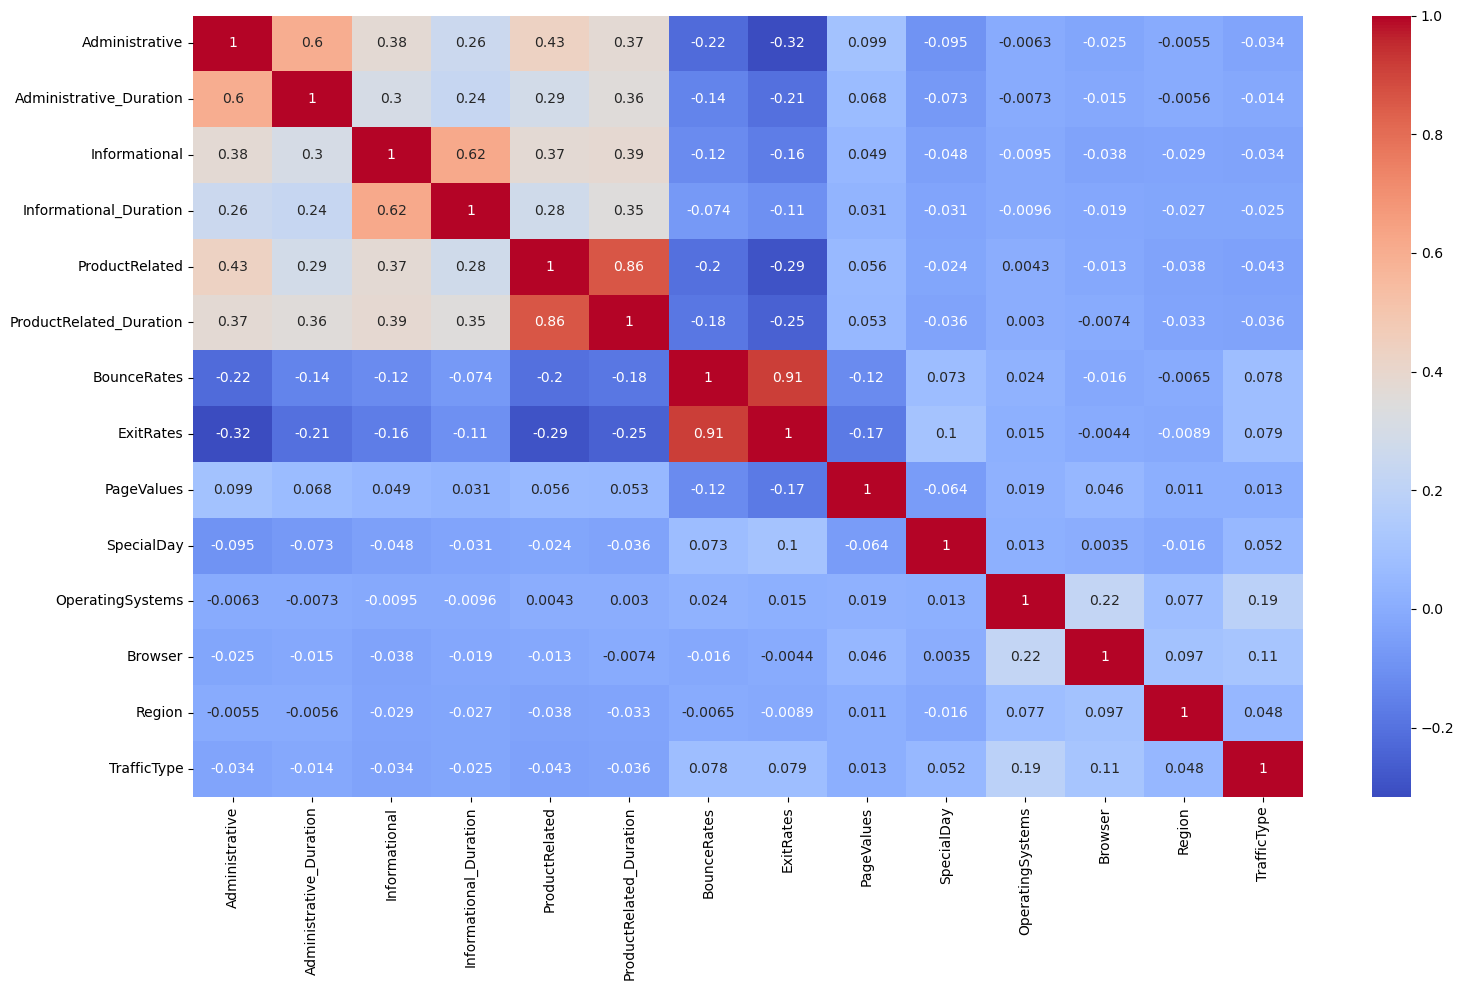

In [75]:
# Correlation HeatMap

corr_matrix = shop_data[num_features].corr()

plt.figure(figsize = (16,10))

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "coolwarm"
)

plt.tight_layout()


# Train Test Split

In [76]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42
) 

# Creating Preprocessing Pipeline

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder

preprocessor = ColumnTransformer(
    transformers = [
        ("numerical" , StandardScaler() , num_features ),
        ("categorical" , OneHotEncoder(handle_unknown = "ignore") , cat_features)
    ]
)

# Model Creation

In [78]:
from sklearn.tree import DecisionTreeClassifier


dtc_model = DecisionTreeClassifier(
    max_depth=6,              # prevents deep overfitting
    min_samples_leaf=30,      # smooths decision boundaries
    class_weight="balanced",  # handles imbalance
    random_state=42
    
)

# Creating Pipeline

In [79]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    steps = [
        ("Preprocessing" , preprocessor ),
        ("Model" , dtc_model)
    ]
)

# Model Training

In [80]:
pipe.fit(X_train , y_train)

,steps,"[('Preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Model Testing and Evaluation

In [81]:
from sklearn.metrics import accuracy_score ,f1_score , classification_report ,confusion_matrix


y_pred = pipe.predict(X_test)


print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.8414436334144363

Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.84      0.90      2055
        True       0.52      0.83      0.64       411

    accuracy                           0.84      2466
   macro avg       0.74      0.84      0.77      2466
weighted avg       0.89      0.84      0.85      2466


Confusion Matrix:
 [[1734  321]
 [  70  341]]


# Plotting Our Decision Tree

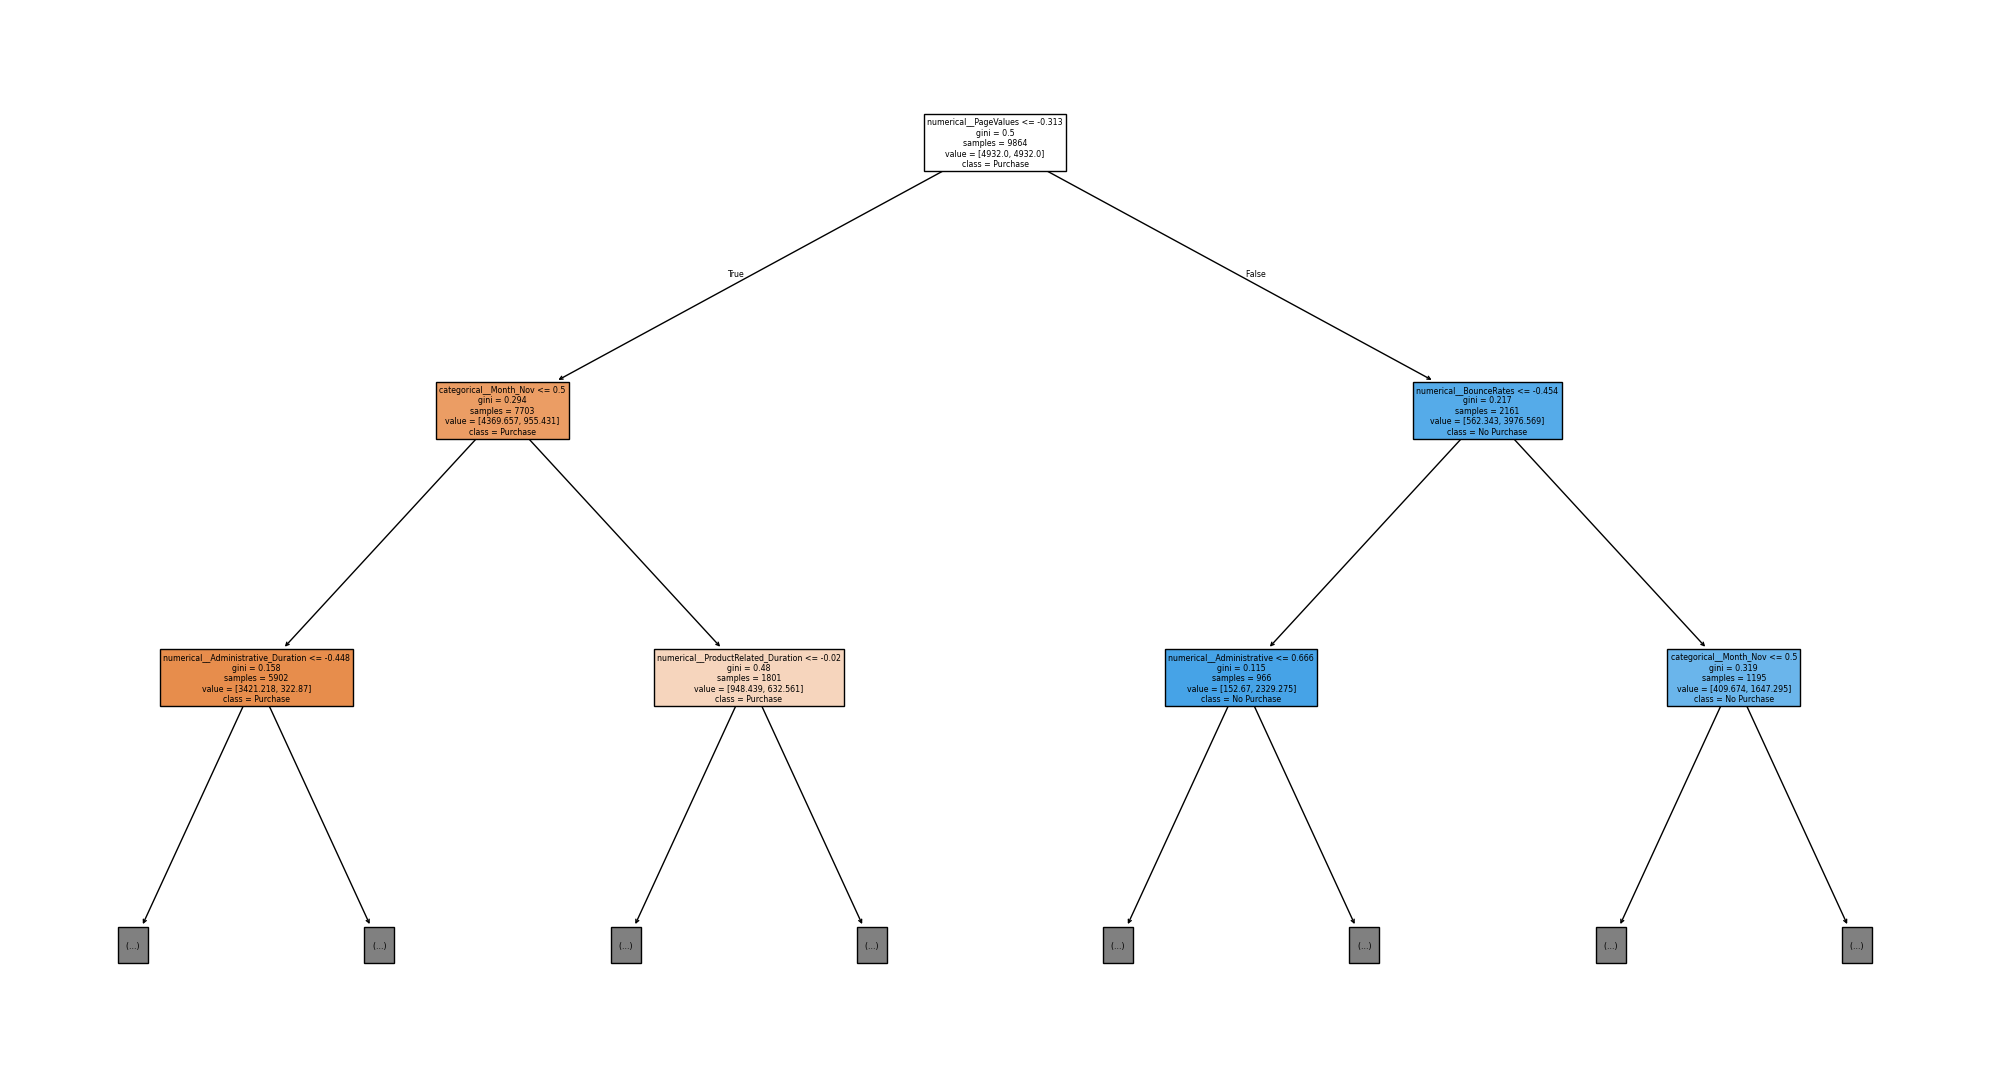

In [102]:
from sklearn.tree import plot_tree

tree_model = pipe.named_steps['Model']
preprocessor = pipe.named_steps['Preprocessing']

feature_names = preprocessor.get_feature_names_out()


plt.figure(figsize = (20,11))
plot_tree(
    tree_model,
    feature_names = feature_names,
    class_names = ["Purchase","No Purchase"],
    filled = True,
    max_depth = 2

)


plt.tight_layout()
plt.show()

# Hyperparameter Tunning

In [91]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "Model__max_depth": [4, 6, 8],
    "Model__min_samples_leaf": [20, 30, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Accuracy:", grid.best_score_)
print("Best params:", grid.best_params_)

Best Accuracy: 0.8481349640018546
Best params: {'Model__max_depth': 8, 'Model__min_samples_leaf': 20}


# Model Loading in model Folder for app creating

In [94]:
import pickle

# Save model
pickle.dump(pipe, open("model/model.pkl", "wb"))

